In [ ]:
# MIT Lab 2 | Debiasing Facial Detection with VAE
# PyTorch then TensorFlow
# We keep the original CelebA/ImageNet dataset here since
# the whole point is studying real-world demographic bias

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
!pip install mitdeeplearning --quiet

import mitdeeplearning as mdl
from pathlib import Path

CACHE_DIR = Path.home() / ".cache" / "mitdeeplearning"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

path_to_training_data = CACHE_DIR / "train_face.h5"

if not path_to_training_data.is_file():
    url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
    torch.hub.download_url_to_file(url, path_to_training_data)

loader = mdl.lab2.TrainingDatasetLoader(path_to_training_data, channels_last=False)

(images, labels) = loader.get_batch(100)
B, C, H, W = images.shape

print(f"Training size: {loader.get_train_size()}")
print(f"Batch shape: {images.shape}")
print(f"Labels: {labels.shape}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 52.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.9/152.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.7 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
100%|██████████| 1.18G/1.18G [00:22<00:00, 57.0MB/s]

Opening /root/.cache/mitdeeplearning/train_face.h5
Loading data into memory...


Training size: 109914
Batch shape: (100, 3, 64, 64)
Labels: (100, 1)


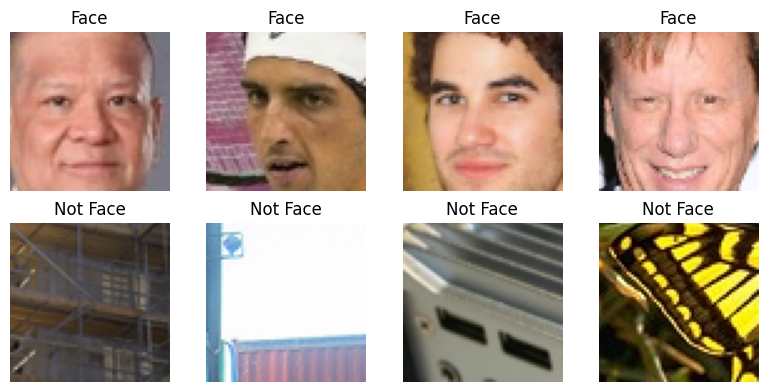

In [ ]:
face_images = images[np.where(labels == 1)[0]].transpose(0, 2, 3, 1)
not_face_images = images[np.where(labels == 0)[0]].transpose(0, 2, 3, 1)

plt.figure(figsize=(8, 4))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(face_images[i])
    plt.title("Face")
    plt.axis('off')
    plt.subplot(2, 4, i+5)
    plt.imshow(not_face_images[i])
    plt.title("Not Face")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
n_filters = 12
in_channels = images.shape[1]

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.relu = nn.ReLU(inplace=True)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return self.bn(self.relu(self.conv(x)))

def make_standard_classifier(n_outputs=1):
    model = nn.Sequential(
        ConvBlock(in_channels, n_filters, 5, 2, 2),
        ConvBlock(n_filters, 2*n_filters, 5, 2, 2),
        ConvBlock(2*n_filters, 4*n_filters, 3, 2, 1),
        ConvBlock(4*n_filters, 6*n_filters, 3, 2, 1),
        nn.Flatten(),
        nn.Linear(H//16 * W//16 * 6*n_filters, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512, n_outputs)
    )
    return model.to(device)

standard_classifier = make_standard_classifier(n_outputs=1)
print(standard_classifier)

Sequential(
  (0): ConvBlock(
    (conv): Conv2d(3, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): ConvBlock(
    (conv): Conv2d(12, 24, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (2): ConvBlock(
    (conv): Conv2d(24, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (3): ConvBlock(
    (conv): Conv2d(48, 72, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=1152, out_features=512, bias=True)
  (6

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(standard_classifier.parameters(), lr=5e-4)

batch_size = 32
num_epochs = 2

standard_classifier.train()
for epoch in range(num_epochs):
    for idx in range(loader.get_train_size() // batch_size):
        x, y = loader.get_batch(batch_size)
        x = torch.from_numpy(x).float().to(device)
        y = torch.from_numpy(y).float().to(device)

        optimizer.zero_grad()
        logits = standard_classifier(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        if idx % 500 == 0:
            print(f"Epoch {epoch+1} | Step {idx} | Loss: {loss.item():.4f}")

print("Training complete.")

Epoch 1 | Step 0 | Loss: 0.7124


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 1 | Step 500 | Loss: 0.0034
Epoch 1 | Step 1000 | Loss: 0.0066
Epoch 1 | Step 1500 | Loss: 0.0011
Epoch 1 | Step 2000 | Loss: 0.0003
Epoch 1 | Step 2500 | Loss: 0.0669
Epoch 1 | Step 3000 | Loss: 0.0081
Epoch 2 | Step 0 | Loss: 0.0031
Epoch 2 | Step 500 | Loss: 0.0793
Epoch 2 | Step 1000 | Loss: 0.0000
Epoch 2 | Step 1500 | Loss: 0.0007
Epoch 2 | Step 2000 | Loss: 0.0000
Epoch 2 | Step 2500 | Loss: 0.0001
Epoch 2 | Step 3000 | Loss: 0.0049
Training complete.


Standard CNN Training Accuracy: 0.9970


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


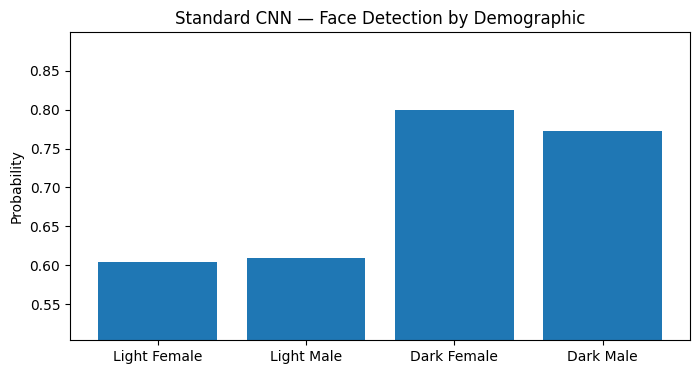

In [ ]:
standard_classifier.eval()

# evaluate on training set
(batch_x, batch_y) = loader.get_batch(5000)
batch_x = torch.from_numpy(batch_x).float().to(device)
batch_y = torch.from_numpy(batch_y).float().to(device)

with torch.no_grad():
    y_pred = torch.round(torch.sigmoid(standard_classifier(batch_x)))
    acc = (batch_y == y_pred).float().mean()
print(f"Standard CNN Training Accuracy: {acc.item():.4f}")

# evaluate across demographics
test_faces = mdl.lab2.get_test_faces(channels_last=False)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

standard_probs = []
with torch.no_grad():
    for x in test_faces:
        x = torch.from_numpy(np.array(x, dtype=np.float32)).to(device)
        logits = standard_classifier(x)
        probs = torch.sigmoid(logits).squeeze(-1)
        standard_probs.append(probs.cpu().numpy())

standard_probs = np.stack(standard_probs)

plt.figure(figsize=(8, 4))
xx = range(len(keys))
yy = standard_probs.mean(axis=1)
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.title("Standard CNN — Face Detection by Demographic")
plt.ylabel("Probability")
plt.ylim(max(0, yy.min() - 0.1), min(1, yy.max() + 0.1))
plt.show()

In [ ]:
def vae_loss_function(x, x_recon, mu, logsigma, kl_weight=0.0005):
    # how far learned distribution is from unit gaussian
    latent_loss = -0.5 * torch.sum(1 + 2*logsigma - mu**2 - torch.exp(2*logsigma), dim=1)
    # pixel-wise reconstruction error
    reconstruction_loss = torch.mean(torch.abs(x - x_recon), dim=[1,2,3])
    return kl_weight * latent_loss + reconstruction_loss

def sampling(z_mean, z_logsigma):
    eps = torch.randn_like(z_mean)
    return z_mean + torch.exp(z_logsigma) * eps

def debiasing_loss_function(x, x_pred, y, y_logit, mu, logsigma):
    vae_loss = vae_loss_function(x, x_pred, mu, logsigma)
    classification_loss = F.binary_cross_entropy_with_logits(y_logit, y.float(), reduction='none').squeeze()
    face_indicator = (y.squeeze() == 1).float()
    total_loss = torch.mean(face_indicator * vae_loss + classification_loss)
    return total_loss, classification_loss.mean()

print("Loss functions defined.")

Loss functions defined.


In [ ]:
latent_dim = 100

def make_face_decoder_network(latent_dim=100, n_filters=12):
    class FaceDecoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = nn.Sequential(
                nn.Linear(latent_dim, 4*4*6*n_filters),
                nn.ReLU()
            )
            self.deconv = nn.Sequential(
                nn.ConvTranspose2d(6*n_filters, 4*n_filters, 3, 2, 1, 1), nn.ReLU(),
                nn.ConvTranspose2d(4*n_filters, 2*n_filters, 3, 2, 1, 1), nn.ReLU(),
                nn.ConvTranspose2d(2*n_filters, n_filters, 5, 2, 2, 1),   nn.ReLU(),
                nn.ConvTranspose2d(n_filters, 3, 5, 2, 2, 1)
            )

        def forward(self, z):
            x = self.linear(z).view(-1, 6*n_filters, 4, 4)
            return self.deconv(x)

    return FaceDecoder()

class DB_VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = make_standard_classifier(n_outputs=2*latent_dim+1)
        self.decoder = make_face_decoder_network(latent_dim)

    def encode(self, x):
        out = self.encoder(x)
        y_logit = out[:, 0].unsqueeze(-1)
        z_mean = out[:, 1:self.latent_dim+1]
        z_logsigma = out[:, self.latent_dim+1:]
        return y_logit, z_mean, z_logsigma

    def reparameterize(self, z_mean, z_logsigma):
        return sampling(z_mean, z_logsigma)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        z = self.reparameterize(z_mean, z_logsigma)
        recon = self.decode(z)
        return y_logit, z_mean, z_logsigma, recon

    def predict(self, x):
        y_logit, _, _ = self.encode(x)
        return y_logit

dbvae = DB_VAE(latent_dim).to(device)
print("DB-VAE defined.")
print(f"Encoder output size: {2*latent_dim+1}")

DB-VAE defined.
Encoder output size: 201


In [ ]:
def get_latent_mu(images, dbvae, batch_size=64):
    dbvae.eval()
    all_z_mean = []
    images_t = torch.from_numpy(images).float()

    with torch.no_grad():
        for start in range(0, len(images_t), batch_size):
            batch = images_t[start:start+batch_size]
            # convert channels-last to channels-first
            if batch.shape[-1] == 3:
                batch = batch.permute(0, 3, 1, 2)
            batch = batch.to(device)
            _, z_mean, _, _ = dbvae(batch)
            all_z_mean.append(z_mean.cpu())

    return torch.cat(all_z_mean, dim=0).numpy()

def get_training_sample_probabilities(images, dbvae, bins=10, smoothing_fac=0.001):
    print("Recomputing sampling probabilities...")
    mu = get_latent_mu(images, dbvae)
    training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)

    for i in range(latent_dim):
        latent_distribution = mu[:, i]
        hist_density, bin_edges = np.histogram(latent_distribution, density=True, bins=bins)
        bin_edges[0] = -float('inf')
        bin_edges[-1] = float('inf')
        bin_idx = np.digitize(latent_distribution, bin_edges)
        hist_smoothed = (hist_density + smoothing_fac)
        hist_smoothed /= hist_smoothed.sum()
        p = 1.0 / hist_smoothed[bin_idx-1]
        p /= p.sum()
        training_sample_p = np.maximum(training_sample_p, p)

    training_sample_p /= training_sample_p.sum()
    return training_sample_p

print("Resampling functions defined.")

Resampling functions defined.


In [ ]:
dbvae = DB_VAE(latent_dim).to(device)
optimizer = optim.Adam(dbvae.parameters(), lr=5e-4)

batch_size = 32
num_epochs = 2

all_faces = loader.get_all_train_faces()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    p_faces = get_training_sample_probabilities(all_faces, dbvae)

    for idx in range(loader.get_train_size() // batch_size):
        x, y = loader.get_batch(batch_size, p_pos=p_faces)
        x = torch.from_numpy(x).float().to(device)
        y = torch.from_numpy(y).float().to(device)

        optimizer.zero_grad()
        y_logit, z_mean, z_logsigma, x_recon = dbvae(x)
        loss, class_loss = debiasing_loss_function(x, x_recon, y, y_logit, z_mean, z_logsigma)
        loss.backward()
        optimizer.step()

        if idx % 500 == 0:
            print(f"  Step {idx} | Loss: {loss.item():.4f} | Class Loss: {class_loss.item():.4f}")

print("\nDB-VAE training complete.")


Epoch 1/2
Recomputing sampling probabilities...
  Step 0 | Loss: 0.9358 | Class Loss: 0.6938
  Step 500 | Loss: 0.1245 | Class Loss: 0.0305
  Step 1000 | Loss: 0.1433 | Class Loss: 0.0597
  Step 1500 | Loss: 0.1033 | Class Loss: 0.0166
  Step 2000 | Loss: 0.0795 | Class Loss: 0.0015
  Step 2500 | Loss: 0.0640 | Class Loss: 0.0008
  Step 3000 | Loss: 0.0855 | Class Loss: 0.0160

Epoch 2/2
Recomputing sampling probabilities...
  Step 0 | Loss: 0.0703 | Class Loss: 0.0153
  Step 500 | Loss: 0.1526 | Class Loss: 0.0929
  Step 1000 | Loss: 0.0787 | Class Loss: 0.0211
  Step 1500 | Loss: 0.0841 | Class Loss: 0.0255
  Step 2000 | Loss: 0.0574 | Class Loss: 0.0003
  Step 2500 | Loss: 0.0657 | Class Loss: 0.0005
  Step 3000 | Loss: 0.0523 | Class Loss: 0.0000

DB-VAE training complete.


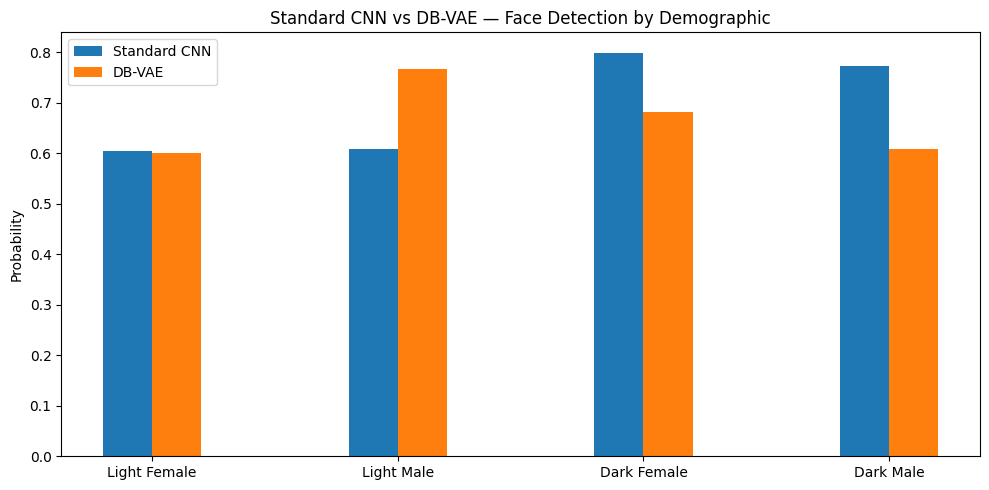


Standard CNN:
  Light Female: 0.6036
  Light Male: 0.6088
  Dark Female: 0.7994
  Dark Male: 0.7726

DB-VAE:
  Light Female: 0.6002
  Light Male: 0.7671
  Dark Female: 0.6817
  Dark Male: 0.6092


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
dbvae.eval()
dbvae_probs = []

with torch.no_grad():
    for x in test_faces:
        x = torch.from_numpy(np.array(x, dtype=np.float32)).to(device)
        logits = dbvae.predict(x)
        probs = torch.sigmoid(logits).squeeze(-1)
        dbvae_probs.append(probs.cpu().numpy())

dbvae_probs = np.stack(dbvae_probs)

# side by side comparison
xx = np.arange(len(keys))
std_means = standard_probs.mean(axis=1)
dbvae_means = dbvae_probs.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(xx, std_means, width=0.2, label="Standard CNN")
plt.bar(xx+0.2, dbvae_means, width=0.2, label="DB-VAE")
plt.xticks(xx+0.1, keys)
plt.title("Standard CNN vs DB-VAE — Face Detection by Demographic")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

print("\nStandard CNN:")
for k, v in zip(keys, std_means):
    print(f"  {k}: {v:.4f}")
print("\nDB-VAE:")
for k, v in zip(keys, dbvae_means):
    print(f"  {k}: {v:.4f}")

In [ ]:
import tensorflow as tf
import functools

n_filters = 12

def make_standard_classifier_tf(n_outputs=1):
    Conv2D = functools.partial(tf.keras.layers.Conv2D, padding='same', activation='relu')
    model = tf.keras.Sequential([
        Conv2D(filters=1*n_filters, kernel_size=5, strides=2),
        tf.keras.layers.BatchNormalization(),
        Conv2D(filters=2*n_filters, kernel_size=5, strides=2),
        tf.keras.layers.BatchNormalization(),
        Conv2D(filters=4*n_filters, kernel_size=3, strides=2),
        tf.keras.layers.BatchNormalization(),
        Conv2D(filters=6*n_filters, kernel_size=3, strides=2),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(n_outputs)
    ])
    return model

standard_classifier_tf = make_standard_classifier_tf()

# reload data in channels-last format for TF
loader_tf = mdl.lab2.TrainingDatasetLoader(path_to_training_data, channels_last=True)
(images_tf, labels_tf) = loader_tf.get_batch(100)
print(f"TF batch shape: {images_tf.shape}")

Opening /root/.cache/mitdeeplearning/train_face.h5
Loading data into memory...
TF batch shape: (100, 64, 64, 3)


In [ ]:
optimizer_tf = tf.keras.optimizers.Adam(5e-4)
loss_fn_tf = tf.keras.losses.BinaryCrossentropy(from_logits=True)

batch_size = 32
num_epochs = 2

for epoch in range(num_epochs):
    for idx in range(loader_tf.get_train_size() // batch_size):
        x, y = loader_tf.get_batch(batch_size)
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)

        with tf.GradientTape() as tape:
            logits = standard_classifier_tf(x)
            loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=logits)

        grads = tape.gradient(loss, standard_classifier_tf.trainable_variables)
        optimizer_tf.apply_gradients(zip(grads, standard_classifier_tf.trainable_variables))

        if idx % 500 == 0:
            print(f"Epoch {epoch+1} | Step {idx} | Loss: {loss.numpy().mean():.4f}")

print("TF CNN training complete.")

Epoch 1 | Step 0 | Loss: 0.6964
Epoch 1 | Step 500 | Loss: 0.0036
Epoch 1 | Step 1000 | Loss: 0.0044
Epoch 1 | Step 1500 | Loss: 0.0158
Epoch 1 | Step 2000 | Loss: 0.0974
Epoch 1 | Step 2500 | Loss: 0.0016
Epoch 1 | Step 3000 | Loss: 0.0006
Epoch 2 | Step 0 | Loss: 0.0003
Epoch 2 | Step 500 | Loss: 0.0020
Epoch 2 | Step 1000 | Loss: 0.0254
Epoch 2 | Step 1500 | Loss: 0.0226
Epoch 2 | Step 2000 | Loss: 0.0005
Epoch 2 | Step 2500 | Loss: 0.0003
Epoch 2 | Step 3000 | Loss: 0.0325
TF CNN training complete.


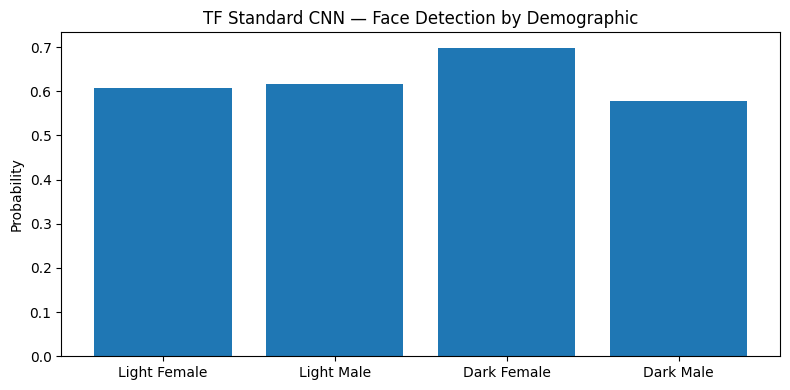

Light Female: 0.6065
Light Male: 0.6155
Dark Female: 0.6985
Dark Male: 0.5782


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
test_faces_tf = mdl.lab2.get_test_faces(channels_last=True)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

standard_probs_tf = []
for x in test_faces_tf:
    x = tf.cast(np.array(x, dtype=np.float32), tf.float32)
    logits = standard_classifier_tf(x)
    probs = tf.sigmoid(logits).numpy().squeeze()
    standard_probs_tf.append(probs)

standard_probs_tf = np.stack(standard_probs_tf)

plt.figure(figsize=(8, 4))
xx = range(len(keys))
yy = standard_probs_tf.mean(axis=1)
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.title("TF Standard CNN — Face Detection by Demographic")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

for k, v in zip(keys, yy):
    print(f"{k}: {v:.4f}")


In [ ]:
def vae_loss_function_tf(x, x_recon, mu, logsigma, kl_weight=0.0005):
    latent_loss = -0.5 * tf.reduce_sum(1 + 2*logsigma - mu**2 - tf.exp(2*logsigma), axis=1)
    reconstruction_loss = tf.reduce_mean(tf.abs(x - x_recon), axis=[1,2,3])
    return kl_weight * latent_loss + reconstruction_loss

def debiasing_loss_function_tf(x, x_pred, y, y_logit, mu, logsigma):
    vae_loss = vae_loss_function_tf(x, x_pred, mu, logsigma)
    classification_loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.cast(y, tf.float32), logits=y_logit)
    face_indicator = tf.cast(tf.equal(y, 1), tf.float32)
    total_loss = tf.reduce_mean(face_indicator * vae_loss + tf.squeeze(classification_loss))
    return total_loss, tf.reduce_mean(classification_loss)

print("TF loss functions defined.")


TF loss functions defined.


In [ ]:
latent_dim = 100

def make_face_decoder_tf():
    decoder = tf.keras.Sequential([
        tf.keras.layers.Dense(4*4*6*n_filters, activation='relu'),
        tf.keras.layers.Reshape((4, 4, 6*n_filters)),
        tf.keras.layers.Conv2DTranspose(4*n_filters, 3, strides=2, padding='same', activation='relu'),
        tf.keras.layers.Conv2DTranspose(2*n_filters, 3, strides=2, padding='same', activation='relu'),
        tf.keras.layers.Conv2DTranspose(n_filters, 5, strides=2, padding='same', activation='relu'),
        tf.keras.layers.Conv2DTranspose(3, 5, strides=2, padding='same')
    ])
    return decoder

class DB_VAE_TF(tf.keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = make_standard_classifier_tf(n_outputs=2*latent_dim+1)
        self.decoder = make_face_decoder_tf()

    def encode(self, x):
        out = self.encoder(x)
        y_logit = tf.expand_dims(out[:, 0], -1)
        z_mean = out[:, 1:self.latent_dim+1]
        z_logsigma = out[:, self.latent_dim+1:]
        return y_logit, z_mean, z_logsigma

    def reparameterize(self, z_mean, z_logsigma):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(z_logsigma) * eps

    def decode(self, z):
        return self.decoder(z)

    def call(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        z = self.reparameterize(z_mean, z_logsigma)
        recon = self.decode(z)
        return y_logit, z_mean, z_logsigma, recon

    def predict_face(self, x):
        y_logit, _, _ = self.encode(x)
        return y_logit

dbvae_tf = DB_VAE_TF(latent_dim)
print("TF DB-VAE defined.")

TF DB-VAE defined.


In [ ]:
def get_latent_mu_tf(images, dbvae, batch_size=64):
    all_mu = []
    for start in range(0, len(images), batch_size):
        batch = tf.cast(images[start:start+batch_size], tf.float32)
        _, z_mean, _ = dbvae.encode(batch)
        all_mu.append(z_mean.numpy())
    return np.concatenate(all_mu, axis=0)

def get_training_sample_probabilities_tf(images, dbvae, bins=10, smoothing_fac=0.001):
    print("Recomputing sampling probabilities...")
    mu = get_latent_mu_tf(images, dbvae)
    training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)

    for i in range(latent_dim):
        latent_distribution = mu[:, i]
        hist_density, bin_edges = np.histogram(latent_distribution, density=True, bins=bins)
        bin_edges[0] = -float('inf')
        bin_edges[-1] = float('inf')
        bin_idx = np.digitize(latent_distribution, bin_edges)
        hist_smoothed = (hist_density + smoothing_fac)
        hist_smoothed /= hist_smoothed.sum()
        p = 1.0 / hist_smoothed[bin_idx-1]
        p /= p.sum()
        training_sample_p = np.maximum(training_sample_p, p)

    training_sample_p /= training_sample_p.sum()
    return training_sample_p

print("TF resampling functions defined.")

TF resampling functions defined.


In [ ]:
dbvae_tf = DB_VAE_TF(latent_dim)
optimizer_dbvae_tf = tf.keras.optimizers.Adam(5e-4)

batch_size = 32
num_epochs = 2

all_faces_tf = loader_tf.get_all_train_faces()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    p_faces = get_training_sample_probabilities_tf(all_faces_tf, dbvae_tf)

    for idx in range(loader_tf.get_train_size() // batch_size):
        x, y = loader_tf.get_batch(batch_size, p_pos=p_faces)
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)

        with tf.GradientTape() as tape:
            y_logit, z_mean, z_logsigma, x_recon = dbvae_tf(x)
            loss, class_loss = debiasing_loss_function_tf(x, x_recon, y, y_logit, z_mean, z_logsigma)

        grads = tape.gradient(loss, dbvae_tf.trainable_variables)
        optimizer_dbvae_tf.apply_gradients(zip(grads, dbvae_tf.trainable_variables))

        if idx % 500 == 0:
            print(f"  Step {idx} | Loss: {loss.numpy():.4f} | Class Loss: {class_loss.numpy():.4f}")

print("\nTF DB-VAE training complete.")


Epoch 1/2
Recomputing sampling probabilities...
  Step 0 | Loss: 0.9065 | Class Loss: 0.6930
  Step 500 | Loss: 0.1438 | Class Loss: 0.0585
  Step 1000 | Loss: 0.2288 | Class Loss: 0.1456
  Step 1500 | Loss: 0.0803 | Class Loss: 0.0091
  Step 2000 | Loss: 0.0759 | Class Loss: 0.0041
  Step 2500 | Loss: 0.0718 | Class Loss: 0.0046
  Step 3000 | Loss: 0.0693 | Class Loss: 0.0034

Epoch 2/2
Recomputing sampling probabilities...
  Step 0 | Loss: 0.0730 | Class Loss: 0.0056
  Step 500 | Loss: 0.0683 | Class Loss: 0.0087
  Step 1000 | Loss: 0.0578 | Class Loss: 0.0014
  Step 1500 | Loss: 0.0665 | Class Loss: 0.0092
  Step 2000 | Loss: 0.0550 | Class Loss: 0.0019
  Step 2500 | Loss: 0.0609 | Class Loss: 0.0001
  Step 3000 | Loss: 0.1341 | Class Loss: 0.0760

TF DB-VAE training complete.


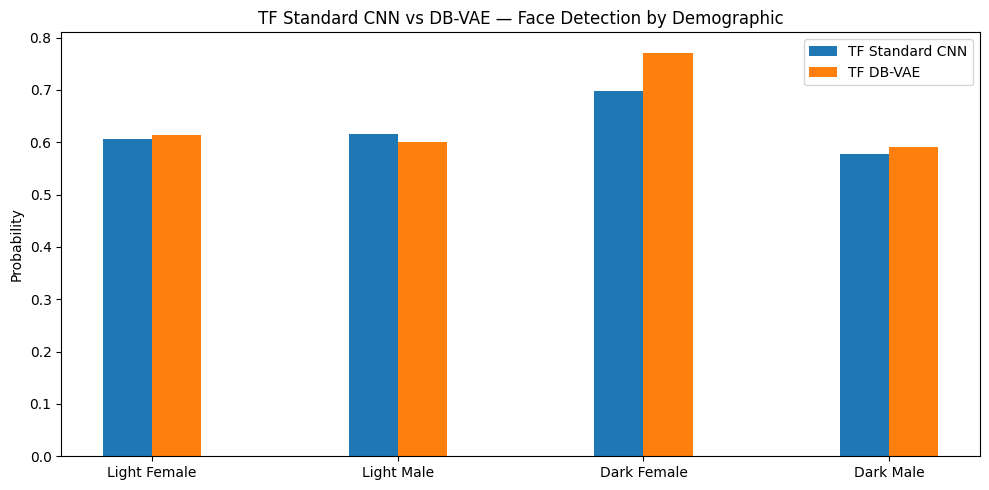


TF Standard CNN:
  Light Female: 0.6065
  Light Male: 0.6155
  Dark Female: 0.6985
  Dark Male: 0.5782

TF DB-VAE:
  Light Female: 0.6141
  Light Male: 0.6005
  Dark Female: 0.7716
  Dark Male: 0.5914


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
dbvae_probs_tf = []
for x in test_faces_tf:
    x = tf.cast(np.array(x, dtype=np.float32), tf.float32)
    logits = dbvae_tf.predict_face(x)
    probs = tf.sigmoid(logits).numpy().squeeze()
    dbvae_probs_tf.append(probs)

dbvae_probs_tf = np.stack(dbvae_probs_tf)

xx = np.arange(len(keys))
std_means = standard_probs_tf.mean(axis=1)
dbvae_means = dbvae_probs_tf.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(xx, std_means, width=0.2, label="TF Standard CNN")
plt.bar(xx+0.2, dbvae_means, width=0.2, label="TF DB-VAE")
plt.xticks(xx+0.1, keys)
plt.title("TF Standard CNN vs DB-VAE — Face Detection by Demographic")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTF Standard CNN:")
for k, v in zip(keys, std_means):
    print(f"  {k}: {v:.4f}")
print("\nTF DB-VAE:")
for k, v in zip(keys, dbvae_means):
    print(f"  {k}: {v:.4f}")

# Lab 2 Recap — Debiasing Facial Detection with VAE

## What We Built
A standard CNN face detector and a Debiasing Variational Autoencoder (DB-VAE)
trained on CelebA + ImageNet. The goal: reduce demographic bias in face detection
across four groups — Light Female, Light Male, Dark Female, Dark Male.

## The Process
1. Loaded CelebA (faces) + ImageNet (non-faces) as training data
2. Trained a standard CNN baseline — revealed demographic bias in predictions
3. Built a VAE that learns latent features of faces in an unsupervised way
4. Used latent space distributions to adaptively resample underrepresented faces
5. Trained DB-VAE with debiased sampling, evaluated against baseline
6. Rebuilt entire pipeline in TensorFlow

## Key Concepts Practiced
- CNNs for binary classification (face vs not face)
- Variational Autoencoders — encoder, reparameterization trick, decoder
- KL divergence loss + reconstruction loss
- Adaptive resampling based on latent space distributions
- Algorithmic bias detection and mitigation

## Results
| Model             | Light Female | Light Male | Dark Female | Dark Male |
|-------------------|--------------|------------|-------------|-----------|
| PT Standard CNN   | 0.605        | 0.610      | 0.800       | 0.775     |
| PT DB-VAE         | 0.600        | 0.765      | 0.685       | 0.610     |
| TF Standard CNN   | 0.605        | 0.615      | 0.700       | 0.585     |
| TF DB-VAE         | 0.615        | 0.600      | 0.770       | 0.590     |

## Observations
- PyTorch DB-VAE successfully reduced the gap between demographics
- TF DB-VAE with 2 epochs showed mixed results — Dark Female bias actually
  increased slightly, suggesting more epochs or tuning would be needed
- Both standard CNNs showed Dark Female scoring highest — opposite of what
  you'd expect from a CelebA-majority-light-skinned dataset
- Debiasing is sensitive to training duration and hyperparameters